<a href="https://colab.research.google.com/github/Emyfoton/Codigos_pregrado/blob/main/Gr%C3%A1ficas_Torque_magn%C3%A9tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exp 1, 2

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [35]:
r = 0.109 #m
d = 0.138 #m
N = 195
miu = 4*np.pi*1e-7
frac = 5/2

def campoB(I):
  B_num = 3*miu*I*r**2*N
  B_dem = r**2 + d**2/4
  B_dem_t = B_dem**frac
  return B_num/B_dem_t

In [36]:
Z = campoB(1)

In [37]:
I_am = 0.001356

In [38]:
dr = 0.0001
dB = 0.00007

In [39]:
r1 = np.array([1.5, 2.0, 2.24, 2.97, 3.5, 4.0, 5.5, 5.94])
r2= r1 * 1.5e-2
r3 = r2*9.77
r = r3*1e-3
I = np.array([2.4, 2.5, 2.7,  2.8,  2.9, 3.0, 3.5, 3.6])
r

array([0.00021982, 0.0002931 , 0.00032827, 0.00043525, 0.00051293,
       0.0005862 , 0.00080602, 0.00087051])

In [40]:
B = I*I_am
B

array([0.0032544, 0.00339  , 0.0036612, 0.0037968, 0.0039324, 0.004068 ,
       0.004746 , 0.0048816])

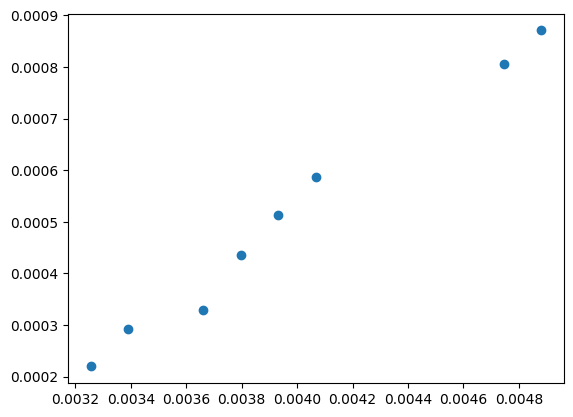

In [41]:
plt.scatter(B,r)

Slope: 0.40039198429886974 ± 0.06430984191165211
Intercept: -0.001081561289821865 ± 0.0002575107561045719
Residuals: [-0.01649384  0.17332463 -0.56081843 -0.03393496  0.19984851  0.38966698
 -0.12674068 -0.02485221]


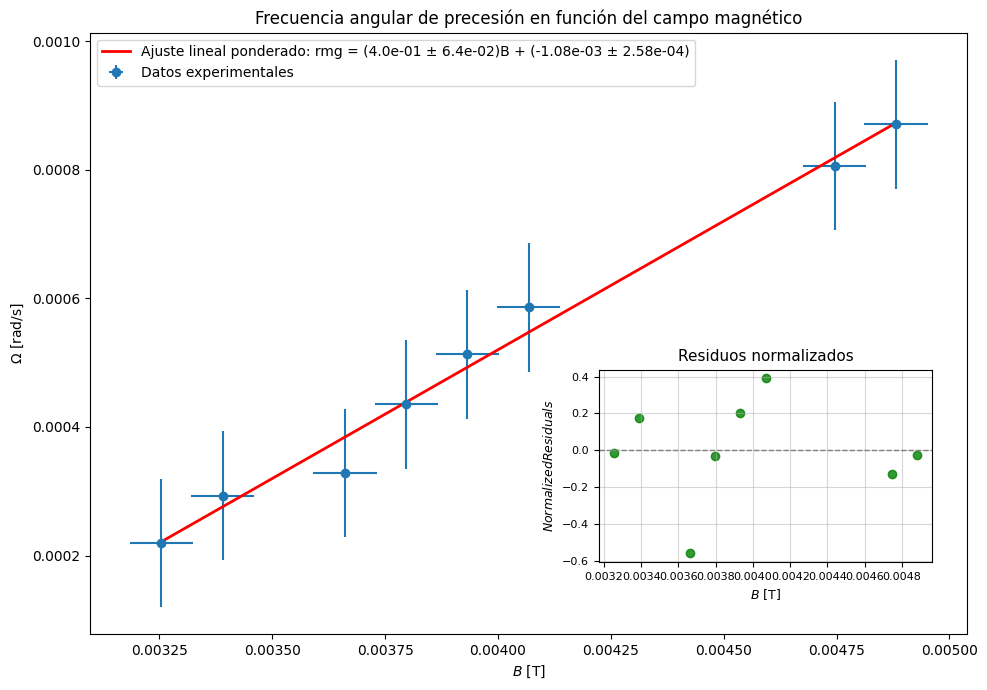

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b

# --- Start of fix ---
# Restore 'r' to its array form as it was likely overwritten as a scalar later in the notebook.
# This re-creates the 'r' array based on its original definition in cell 2Qi5y8ooQ4KK.
r1 = np.array([1.5, 2.0, 2.24, 2.97, 3.5, 4.0, 5.5, 5.94])
r2 = r1 * 1.5e-2
r3 = r2 * 9.77
r = r3 * 1e-3
# --- End of fix ---


# Perform the curve fitting considering the uncertainties
# Changed sigma=dB to sigma=dr for consistency with yerr
popt, pcov = curve_fit(linear_function, B, r, sigma=dr, absolute_sigma=True)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])

## Setting variables
x = B
y = r
yerr = dr
xerr = dB

# Predict the Y values
Y_pred = linear_function(x, *popt)

# Calculate normalized residuals
residuals = (y - Y_pred)/yerr

print(f"Slope: {slope} \u00b1 {slope_std_err}")
print(f"Intercept: {intercept} \u00b1 {intercept_std_err}")
print(f"Residuals: {residuals}")

# Create the main figure
fig, ax1 = plt.subplots(figsize=(10, 7))

# Plot the experimental data with uncertainties
ax1.errorbar(
    x, y,
    yerr=yerr,
    xerr=xerr,
    fmt='o',
    label='Datos experimentales'
)

# Create smooth x values for the regression line
x_fit = np.linspace(np.min(x), np.max(x), 200)
y_fit = linear_function(x_fit, *popt)

# Plot the regression line
ax1.plot(
    x_fit,
    y_fit,
    color='red',
    linewidth=2,
    label=f'Ajuste lineal ponderado: '
          f'rmg = ({slope:.1e} \u00b1 {slope_std_err:.1e})B + '
          f'({intercept:.2e} \u00b1 {intercept_std_err:.2e})'
)

# Labels and title of the main plot
ax1.set_xlabel(r'$B$ [T]')
ax1.set_ylabel(r'$\Omega$ [rad/s]')
ax1.set_title('Frecuencia angular de precesión en función del campo magnético')

ax1.legend(loc='upper left')


# ---------------------------------------------------------
# Inset plot: normalized residuals
# ---------------------------------------------------------

# Create a small axes inside the main plot
ax2 = ax1.inset_axes([0.58, 0.12, 0.38, 0.32])

# Plot normalized residuals
ax2.scatter(
    x,
    residuals,
    alpha=0.8,
    c="green"
)

# Horizontal line at zero
ax2.axhline(
    0,
    linestyle='--',
    linewidth=1,
    c="grey"
)

# Labels
ax2.set_xlabel(r'$B$ [T]', fontsize=9)
ax2.set_ylabel('$Normalized Residuals$', fontsize=9)

# Title
ax2.set_title('Residuos normalizados', fontsize=11)

# Make tick labels smaller
ax2.tick_params(axis='both', labelsize=8)

# Add grid
ax2.grid(True, alpha=0.5)


# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    'Weighted_linear_regression_with_normalized_residuals_curve_fit.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

In [43]:
I_osc = np.array([
    1.0,
    1.2,
    1.5,
    1.8,
    2.2,
    2.6,
    3.0,
    3.4,
    3.7,
    4.0
])

T = np.array([
    33.81,
    29.24,
    25.86,
    24.23,
    22.29,
    19.76,
    19.36,
    17.91,
    17.63,
    17.06
])

In [44]:
B_osc = I_am * I_osc
B_osc1 = 1/B_osc
B_osc1

array([737.46312684, 614.5526057 , 491.64208456, 409.70173714,
       335.2105122 , 283.63966417, 245.82104228, 216.90091966,
       199.31435861, 184.36578171])

In [45]:
T_osc = T/20
T_osc
t_prueba = T_osc**2
t_prueba

array([2.85779025, 2.137444  , 1.671849  , 1.46773225, 1.24211025,
       0.976144  , 0.937024  , 0.80192025, 0.77704225, 0.727609  ])

In [46]:
dT = 0.01
dB1 = 0.00007


Slope: 0.0035242602361340177 ± 4.6179695959244234e-05
Intercept: 0.04574093086413064 ± 0.01563012292171315
Residuals: [ 6.30101584 -2.535576   -4.1209041  -0.90401245  0.67295829 -3.5028806
  1.28851987 -0.459853    1.63730293  1.88247806]


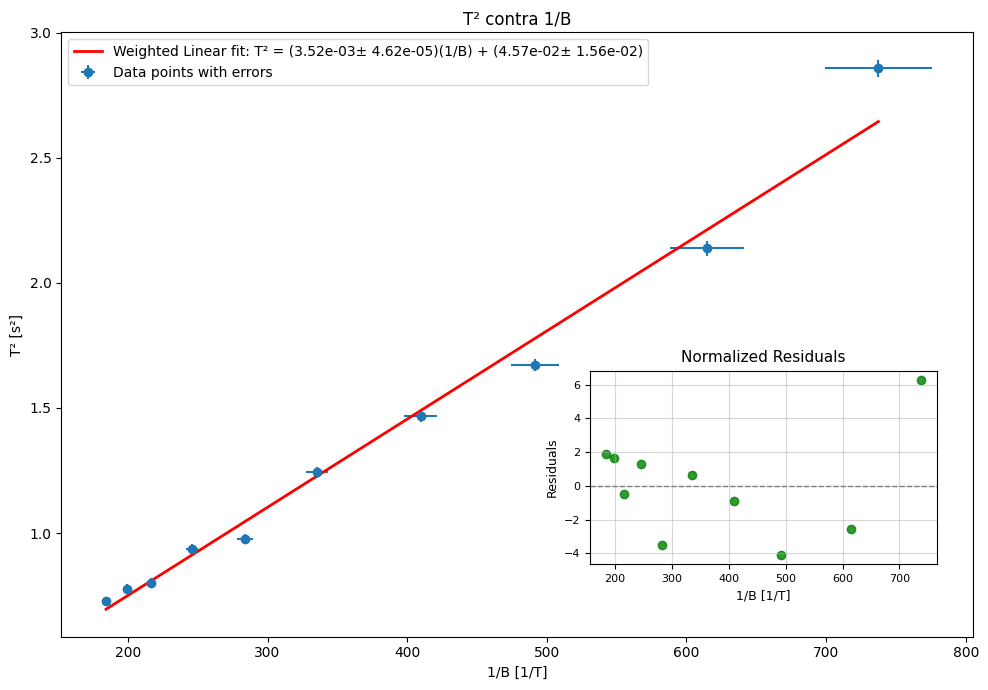

miu = 0.4123 ± 0.0054


In [77]:
def linear_function(X, a, b):
    return a * X + b
x1 = B_osc1
y1 = T_osc**2
yerr1 = 2 * (dT) * T_osc
xerr1 = dB1 * B_osc1**2
popt, pcov = curve_fit(linear_function, B_osc1, T_osc**2, sigma=yerr1, absolute_sigma=True)

slope1 = popt[0]
intercept1 = popt[1]

slope_std_err1 = np.sqrt(pcov[0, 0])
intercept_std_err1 = np.sqrt(pcov[1, 1])

Y_pred1 = linear_function(x1, *popt)

residuals1 = (y1 - Y_pred1)/yerr1

print(f"Slope: {slope1} \u00b1 {slope_std_err1}")
print(f"Intercept: {intercept1} \u00b1 {intercept_std_err1}")
print(f"Residuals: {residuals1}")

fig, ax1 = plt.subplots(figsize=(10, 7))

ax1.errorbar(
    x1, y1,
    yerr=yerr1,
    xerr=xerr1,
    fmt='o',
    label='Data points with errors'
)

x_fit1 = np.linspace(np.min(x1), np.max(x1), 200)
y_fit1 = linear_function(x_fit1, *popt)

ax1.plot(
    x_fit1,
    y_fit1,
    color='red',
    linewidth=2,
    label=f'Weighted Linear fit: T\u00b2 = ({slope1:.2e}\u00b1 {slope_std_err1:.2e})(1/B) + ({intercept1:.2e}\u00b1 {intercept_std_err1:.2e})'
)

ax1.set_xlabel('1/B [1/T]')
ax1.set_ylabel('T\u00b2 [s\u00b2]')
ax1.legend(loc='upper left')
ax1.set_title('T\u00b2 contra 1/B')

ax2 = ax1.inset_axes([0.58, 0.12, 0.38, 0.32])

ax2.scatter(
    x1,
    residuals1,
    alpha=0.8,
    c="green"
)

ax2.axhline(
    0,
    linestyle='--',
    linewidth=1,
    c="grey"
)

ax2.set_xlabel('1/B [1/T]', fontsize=9)
ax2.set_ylabel('Residuals', fontsize=9)

ax2.set_title('Normalized Residuals', fontsize=11)
ax2.tick_params(axis='both', labelsize=8)
ax2.grid(True, alpha=0.5)
plt.tight_layout()

plt.savefig(
    'Weighted_linear_regression_with_normalized_residuals_curve_fit_T2_vs_invB.pdf',
    format='pdf',
    bbox_inches='tight'
)
plt.show()

b = slope1
db = slope_std_err1

m = 0.1415
r = 0.0255

miu_NUM = 4*(np.pi**2)*2*m*r**2
miu_dem = 5*b
miu = miu_NUM/miu_dem

sigma_miu = miu * (db/b)

print(f"miu = {miu:.4f} \u00b1 {sigma_miu:.4f}")

In [48]:
b = slope1

In [49]:
m = 0.1415

In [50]:
miu_NUM = 4*(np.pi**2)*2*m*0.027**2
miu_dem = 5*b
miu = miu_NUM/miu_dem
miu

np.float64(0.4622061570366081)

In [51]:
b = slope1
db = slope_std_err1   # <- la incertidumbre que sale del ajuste

m = 0.1415
r = 0.0255

miu_NUM = 4*(np.pi**2)*2*m*r**2
miu_dem = 5*b
miu = miu_NUM/miu_dem

# Si m y r son valores exactos (sin incertidumbre propia):
sigma_miu = miu * (db/b)

print(f"miu = {miu:.4f} ± {sigma_miu:.4f}")

miu = 0.4123 ± 0.0054


In [52]:
print(b, db)
print(miu, sigma_miu)

0.0035242602361340177 4.6179695959244234e-05
0.41227647957894975 0.0054022124367831366


In [53]:
h = 1e-5
def derivada_numerica(f,x):
 return (f(x+h) - f(x - h)) /2 * h

def reflection_coefficient(theta_i,theta_t):
    return (np.tan(theta_i - theta_t))**2/ (np.tan(theta_i + theta_t))**2


In [54]:
reflection_coefficient(45,34.5)

np.float64(1.6760350707649203)

# Exp 3

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import requests
import io

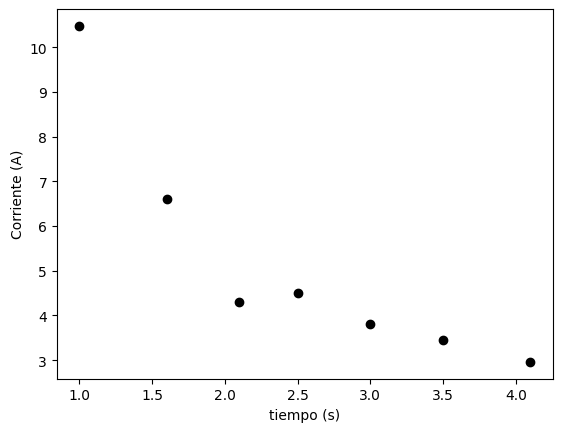

In [56]:
x= np.array([1.0, 1.6, 2.1, 2.5, 3, 3.5, 4.1])
y= np.array([10.48, 6.6, 4.29, 4.5, 3.8, 3.45, 2.96])
errorxy = np.full_like(x, 0.01, dtype=float)

plt.scatter(x, y, c="k")
plt.xlabel('tiempo (s)')
plt.ylabel('Corriente (A)')
plt.show()

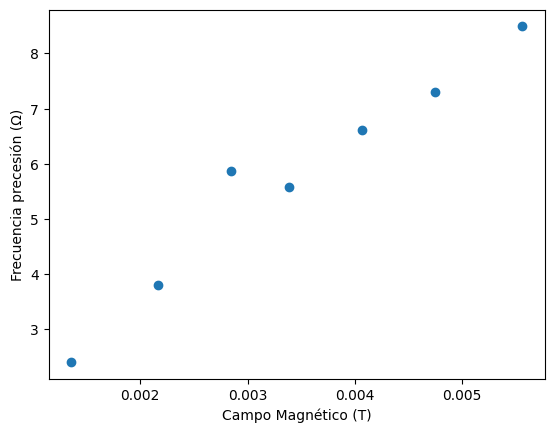

In [57]:
x1= np.array([0.001356, 0.002169, 0.002847, 0.003390, 0.004068, 0.004746, 0.005559])
y1= np.array([2.40, 3.81, 5.87, 5.58, 6.61, 7.30, 8.49])
errorx1= np.array([0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01])
errory1= np.full_like(y, 0.07E-3, dtype=float)

plot1= plt.scatter (x1, y1)
plt.ylabel('Frecuencia precesión (Ω)')
plt.xlabel('Campo Magnético (T)')
plot1

Slope: 1231.1550264855016 ± 3.71855286703881
Intercept: 1.626079917045744 ± 0.015142980039981541
Residuals: [-44.77630665 -24.32275847  73.88217226 -21.96954568  -2.44185648
 -16.91416727   1.99292907]


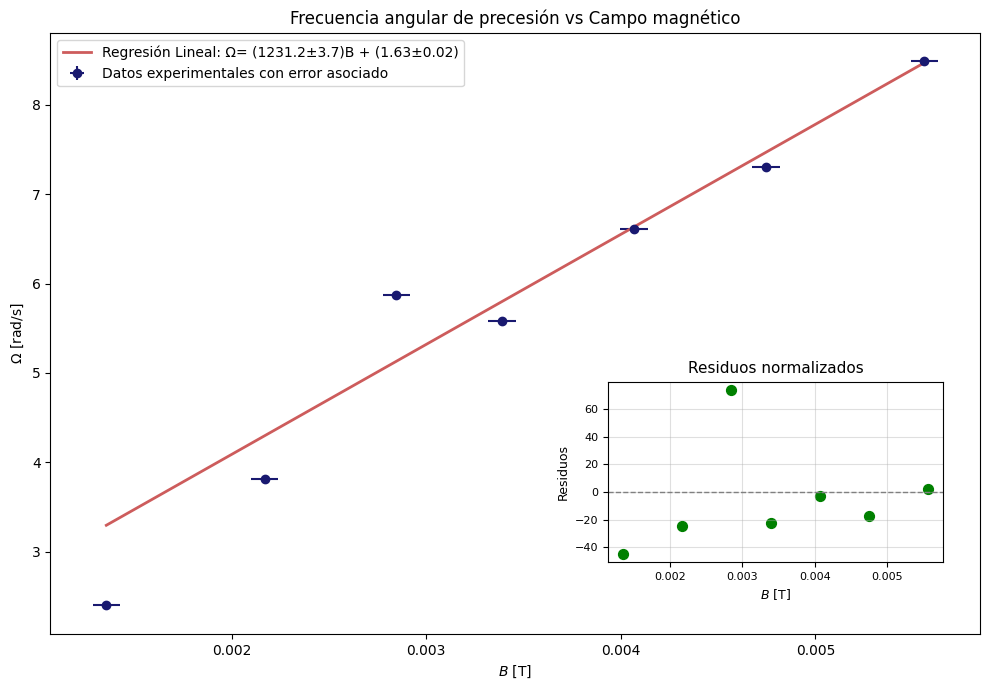

In [ ]:
# Define the linear function for curve fitting
def linear_function(X, a, b):
    return a * X + b


# Perform the curve fitting considering the uncertainties
popt, pcov = curve_fit(
    linear_function,
    x1,
    y1,
    sigma=errorx1,
    absolute_sigma=True
)

# Get the slope and intercept
slope = popt[0]
intercept = popt[1]

# Get the standard errors for the parameters
slope_std_err = np.sqrt(pcov[0, 0])
intercept_std_err = np.sqrt(pcov[1, 1])


# Setting variables
yerr = errorx1
xerr = errory1


# Predict the Y values
Y_pred = linear_function(x1, *popt)


# Calculate normalized residuals
residuals = (y1 - Y_pred) / yerr


print(f"Slope: {slope} ± {slope_std_err}")
print(f"Intercept: {intercept} ± {intercept_std_err}")
print(f"Residuals: {residuals}")


# =====================================
# MAIN FIGURE
# =====================================

fig, ax1 = plt.subplots(figsize=(10, 7))


# Experimental data
ax1.errorbar(
    x1,
    y1,
    yerr=yerr,
    xerr=xerr,
    fmt='o',
    c="midnightblue",
    label='Datos experimentales con error asociado'
)


# Linear regression
ax1.plot(
    x1,
    Y_pred,
    color='indianred',
    linewidth=2,
    label=(
        f'Regresión Lineal: '
        f'Ω= ({slope:.1f}±{slope_std_err:.1f})B + '
        f'({intercept:.2f}±{intercept_std_err:.2f})'
    )
)


# Axis labels
ax1.set_xlabel(r'$B$ [T]')
ax1.set_ylabel(r'$\Omega$ [rad/s]')

ax1.set_title(
    'Frecuencia angular de precesión vs Campo magnético'
)

ax1.legend(loc='upper left')


# =====================================
# RESIDUALS INSET
# =====================================

ax_res = ax1.inset_axes(
    [0.60, 0.12, 0.36, 0.30]
)


# Residuals
ax_res.scatter(
    x1,
    residuals,
    color='green',
    s=50
)


# Zero line
ax_res.axhline(
    0,
    color='grey',
    linewidth=1,
    linestyle='--'
)


# Inset labels
ax_res.set_title(
    'Residuos normalizados',
    fontsize=11
)

ax_res.set_xlabel(
    r'$B$ [T]',
    fontsize=9
)

ax_res.set_ylabel(
    r'Residuos',
    fontsize=9
)


# Smaller ticks
ax_res.tick_params(
    axis='both',
    labelsize=8
)


# Grid
ax_res.grid(
    True,
    alpha=0.4
)


plt.tight_layout()
plt.show()

In [59]:
slope: 1231.1550264855016
const= 2*np.pi*5*2/5*0.027**2*0.0425
miu= slope*const
miu_incer= 0.06
print("μ=" ,f'({miu:.2f} ± {miu_incer})')


μ= (0.48 ± 0.06)
